# Prodigy InfoTech Internship Task 4

In [1]:
# importing libraries
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [2]:
# loading the train and validation datasets
twi_train=pd.read_csv(r"C:\Users\LENOVO\Downloads\Twitter Sentiment Analysis\twitter_training.csv")
twi_val=pd.read_csv(r"C:\Users\LENOVO\Downloads\Twitter Sentiment Analysis\twitter_validation.csv")

In [3]:
print(twi_train.head())

   2401  Borderlands  Positive  \
0  2401  Borderlands  Positive   
1  2401  Borderlands  Positive   
2  2401  Borderlands  Positive   
3  2401  Borderlands  Positive   
4  2401  Borderlands  Positive   

  im getting on borderlands and i will murder you all ,  
0  I am coming to the borders and I will kill you...     
1  im getting on borderlands and i will kill you ...     
2  im coming on borderlands and i will murder you...     
3  im getting on borderlands 2 and i will murder ...     
4  im getting into borderlands and i can murder y...     


In [4]:
# dataset column names
twi_train.columns

Index(['2401', 'Borderlands', 'Positive',
       'im getting on borderlands and i will murder you all ,'],
      dtype='object')

In [5]:
# adding column names
twi_train.columns=['tweet_id', 'entity', 'sentiment', 'content']
twi_val.columns=['tweet_id', 'entity', 'sentiment', 'content']

In [6]:
twi_train.columns

Index(['tweet_id', 'entity', 'sentiment', 'content'], dtype='object')

In [7]:
# checking for null values
twi_train.isnull().sum()

tweet_id       0
entity         0
sentiment      0
content      686
dtype: int64

In [8]:
twi_val.isnull().sum()

tweet_id     0
entity       0
sentiment    0
content      0
dtype: int64

In [9]:
# dropping the null values
twi_train.dropna(inplace=True)
twi_val.dropna(inplace=True)

In [10]:
twi_train_val=pd.concat([twi_train,twi_val],ignore_index=True)

# Visualizing Sentiment Patterns

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

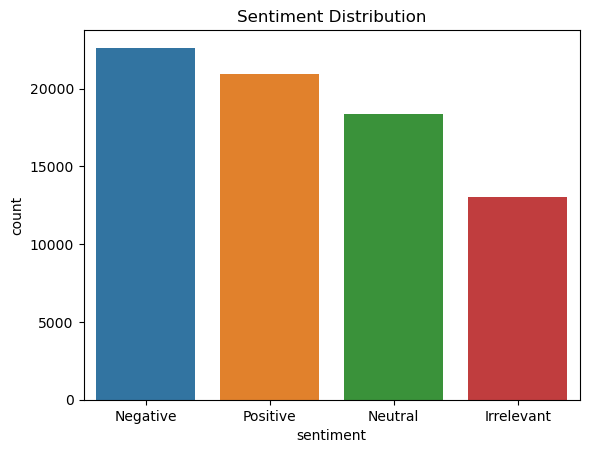

In [12]:
# Countplot for sentiment distribution
sns.countplot(data=twi_train_val,x='sentiment',order=twi_train_val['sentiment'].value_counts().index)
plt.title('Sentiment Distribution')
plt.show()

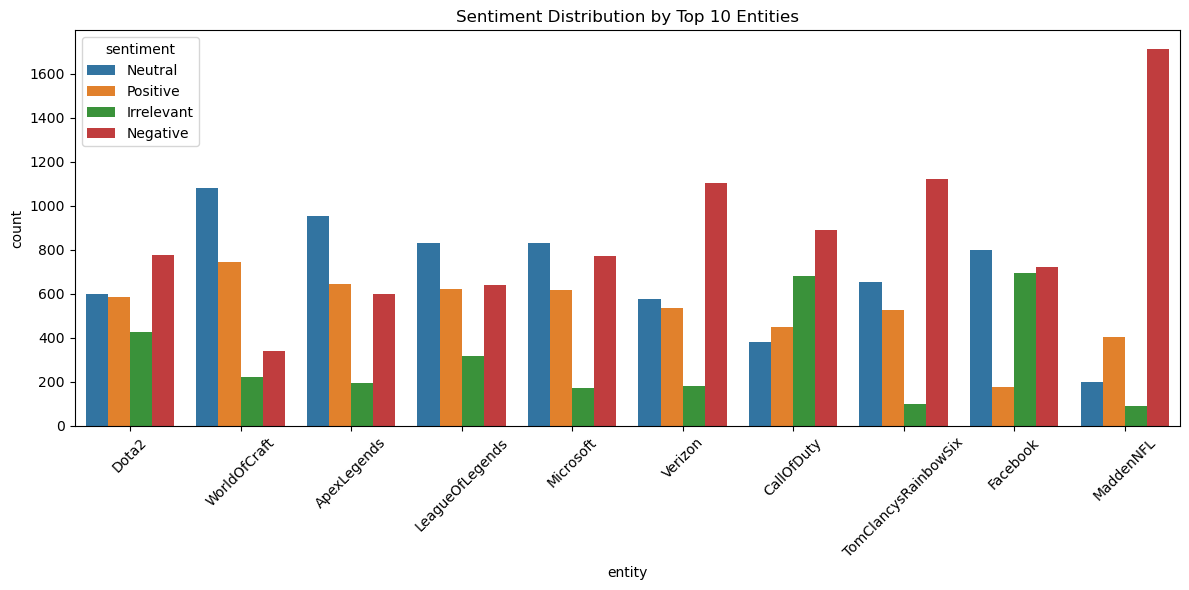

In [13]:
# Countplot for Sentiment Distribution by Top 10 Entities
top_entities=twi_train_val['entity'].value_counts().head(10).index
filtered=twi_train_val[twi_train_val['entity'].isin(top_entities)]

plt.figure(figsize=(12,6))
sns.countplot(data=filtered,x='entity',hue='sentiment')
plt.title('Sentiment Distribution by Top 10 Entities')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

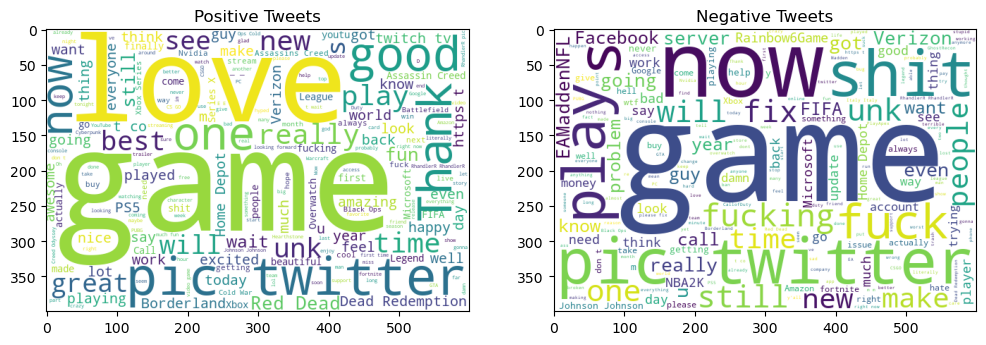

In [19]:
# Word Clouds for Positive/Negative Tweets
from wordcloud import WordCloud

positive_text=' '.join(twi_train_val[twi_train_val['sentiment']=='Positive']['content'])
negative_text=' '.join(twi_train_val[twi_train_val['sentiment']=='Negative']['content'])

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(WordCloud(width=600,height=400,background_color='white').generate(positive_text))
plt.title('Positive Tweets')

plt.subplot(1,2,2)
plt.imshow(WordCloud(width=600,height=400,background_color='white').generate(negative_text))
plt.title('Negative Tweets')

plt.show()

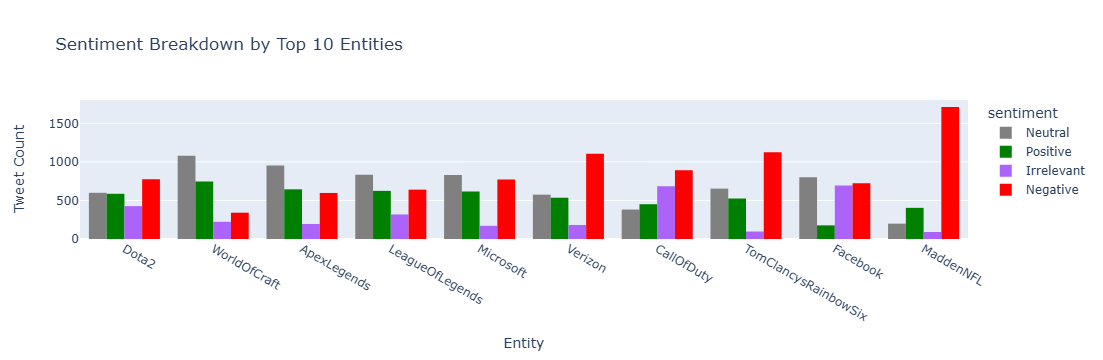

In [15]:
# Interactive Sentiment Breakdown by Brand
import plotly.express as px

top_entities=twi_train_val['entity'].value_counts().head(10).index
filtered=twi_train_val[twi_train_val['entity'].isin(top_entities)]

fig=px.histogram(filtered,x="entity",color="sentiment",barmode="group",
                 title="Sentiment Breakdown by Top 10 Entities",
                 color_discrete_map={
                     'Positive':'green',
                     'Negative':'red',
                     'Neutral':'gray'
                 })
fig.update_layout(xaxis_title="Entity",yaxis_title="Tweet Count")
fig.show()

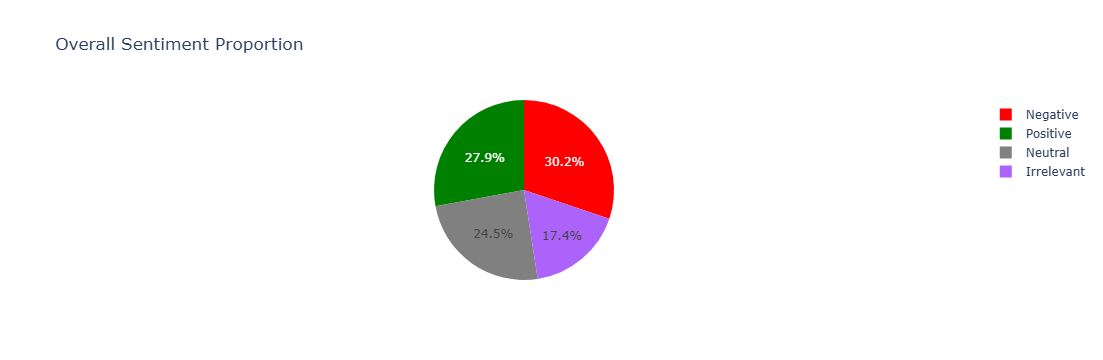

In [16]:
# Pie Chart of Sentiment Proportions
sentiment_counts=twi_train_val['sentiment'].value_counts().reset_index()
sentiment_counts.columns=['Sentiment','Count']
fig=px.pie(sentiment_counts,names='Sentiment',values='Count',
           color='Sentiment',
           color_discrete_map={'Positive':'green','Negative':'red','Neutral':'gray'},
           title="Overall Sentiment Proportion")
fig.show()               

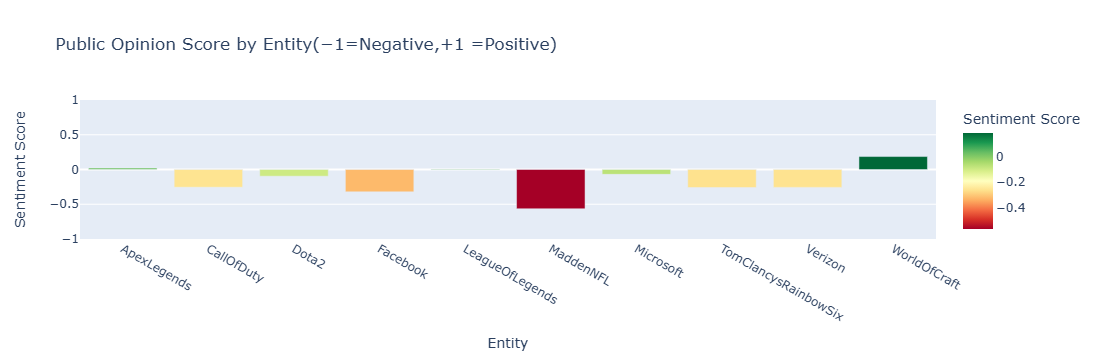

In [17]:
# Entity Sentiment Score Plot
import pandas as pd
import plotly.express as px

top_entities=twi_train_val['entity'].value_counts().head(10).index
filtered_df=twi_train_val[twi_train_val['entity'].isin(top_entities)]
sentiment_map={
    'Positive':1,
    'Neutral':0,
    'Negative':-1
}
filtered_df['sentiment_score']=filtered_df['sentiment'].map(sentiment_map)
entity_sentiment=filtered_df.groupby('entity')['sentiment_score'].mean().reset_index()
fig = px.bar(entity_sentiment, x='entity', y='sentiment_score',
             color='sentiment_score',color_continuous_scale='RdYlGn',
             title='Public Opinion Score by Entity(−1=Negative,+1 =Positive)',
             labels={'sentiment_score':'Sentiment Score', 'entity':'Entity'})
fig.update_layout(yaxis=dict(range=[-1,1]))
fig.show()